# 2 . Opciones exoticas y dependientes de trayectoria

Sobre el mismo motor de autoria programatica (`when`/`cashflow`/`trigger`/`if_`/`both`,
`PLAN_PRODUCTS.md §7`), este notebook construye familias de productos que Black-Scholes no
puede precisar en cerrado: barreras (knock-in/knock-out, single y double), un digital/binario,
un asiatico aritmetico nativo (`q.average`, `PLAN_IMPROVE_NOTEBOOK.md` Fase 2 -- con la replica
manual via `add`/`div` como celda de verificacion cruzada, no como unico camino), un lookback
real (`q.running_max`/`q.running_min`, imposible de escribir antes de esa misma fase), una
estrategia take-profit/stop-loss, y combinaciones (`straddle`/`strangle`) via `both`. Todo se
precia con `PayoffPriceQ` (y `PayoffHitProbabilityQ` para probabilidades de toque), y la
identidad *knock-in + knock-out = vanilla* sirve de test de regresion visual.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../../../build/clients/python")
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

import engine
import engine_typed as q
from engine_typed import greeks

print("modulo engine importado desde:", engine.__file__)


modulo engine importado desde: S:\Projects\engine_quant\clients\python\notebooks\../../../build/clients/python\engine.cp312-win_amd64.pyd


## 1. Mercado y plantillas de barrera


In [2]:
import math

S0, R, Q_DIV, SIGMA, T = 180.0, 0.05, 0.006, 0.28, 1.0
OBS = "EQ.SPOT.AAPL"
MONITORING = [0.25, 0.5, 0.75, 1.0]

eng = engine.Engine()
model = eng.create_model("GBM", {"s0": S0, "r": R, "q": Q_DIV, "sigma": SIGMA, "observable": OBS})
market = engine.MarketSnapshot(pillars=[T], zero_rates=[R])
execution = engine.ExecutionContext({"backend": "cpu"})
pricing = engine.PricingContext({"pricing_date": 0.0, "n_paths": 150_000.0, "n_steps": 1.0, "seed": 23.0})


def vanilla_call_contract(strike):
    """Delega en engine_typed.payoff.call_leg (PLAN_IMPROVE_NOTEBOOK2.md Fase 6): unica fuente
    de verdad para una pata call vainilla, compartida con 09_option_strategies_and_greeks.ipynb
    -- antes reimplementada aqui a mano (ver vanilla_call_contract_manual, celda de verificacion
    cruzada, no el unico camino)."""
    return q.call_leg(OBS, strike, 1.0, T)


def vanilla_call_contract_manual(strike):
    """Version local horneada a mano (PRE-Fase 6, celda de verificacion cruzada): la que usaba
    este notebook antes de que engine_typed.payoff expusiera call_leg."""
    return q.when(T, q.cashflow("USD", q.maximum(q.fixing(OBS, T) - strike, 0.0)))


def up_and_in(event_id, barrier, underlying):
    condition = q.greater_equal(q.current(OBS), barrier)
    return q.trigger(event_id, MONITORING, condition, "discrete", "at_hit", 0, True, underlying, q.zero())


def up_and_out(event_id, barrier, underlying):
    condition = q.greater_equal(q.current(OBS), barrier)
    return q.trigger(event_id, MONITORING, condition, "discrete", "at_hit", 0, True, q.zero(), underlying)


def down_and_in(event_id, barrier, underlying):
    condition = q.less_equal(q.current(OBS), barrier)
    return q.trigger(event_id, MONITORING, condition, "discrete", "at_hit", 0, True, underlying, q.zero())


def double_knock_out(event_id, low, high, underlying):
    spot = q.current(OBS)
    condition = q.any_of([q.less_equal(spot, low), q.greater_equal(spot, high)])
    return q.trigger(event_id, MONITORING, condition, "discrete", "at_hit", 0, True, q.zero(), underlying)


def price_contract(contract, trade_id, measures=("PayoffPriceQ",)):
    product = eng.create_product("Payoff", q.PayoffProduct(id=trade_id, contract=contract).to_params())
    return eng.price(product, list(measures), model, market, pricing, execution)


# Verificacion cruzada: call_leg (motor) vs horneado a mano deben dar el MISMO precio exacto
# (misma seed/n_paths, PLAN_IMPROVE_NOTEBOOK2.md Fase 6).
call_native_check = price_contract(vanilla_call_contract(S0), "CALL_NATIVE_CHECK")["PayoffPriceQ"].scalar
call_manual_check = price_contract(vanilla_call_contract_manual(S0), "CALL_MANUAL_CHECK")["PayoffPriceQ"].scalar
assert call_native_check == call_manual_check, f"call_leg={call_native_check} manual={call_manual_check}"
print(f"call_leg vs horneado a mano: {call_native_check:.6f} == {call_manual_check:.6f} (coinciden exactamente)")

print(f"S0={S0}  sigma={SIGMA:.0%}  monitoring={MONITORING}")


call_leg vs horneado a mano: 23.500697 == 23.500697 (coinciden exactamente)
S0=180.0  sigma=28%  monitoring=[0.25, 0.5, 0.75, 1.0]


## 2. Knock-in + knock-out = vanilla

Exactamente una de las dos ramas paga en cada trayectoria: la suma de precios (evaluados con
la MISMA `PricingContext`/semilla, pero como dos simulaciones independientes, no numeros
aleatorios comunes explicitos) debe reproducir el precio vanilla dentro del ruido Monte Carlo.


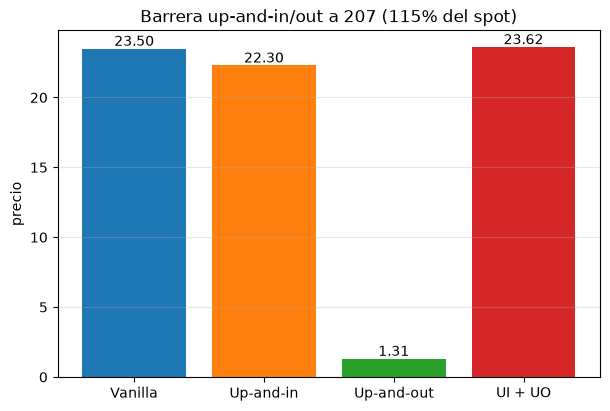

vanilla=23.501  UI+UO=23.616  diferencia=0.115


In [3]:
barrier = S0 * 1.15
vanilla_contract = vanilla_call_contract(S0)
ui_contract = up_and_in("UI", barrier, vanilla_contract)
uo_contract = up_and_out("UO", barrier, vanilla_contract)

vanilla_price = price_contract(vanilla_contract, "VANILLA")["PayoffPriceQ"].scalar
ui_price = price_contract(ui_contract, "UI")["PayoffPriceQ"].scalar
uo_price = price_contract(uo_contract, "UO")["PayoffPriceQ"].scalar

labels = ["Vanilla", "Up-and-in", "Up-and-out", "UI + UO"]
values = [vanilla_price, ui_price, uo_price, ui_price + uo_price]

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
ax.bar(labels, values, color=colors)
for i, v in enumerate(values):
    ax.text(i, v + 0.2, f"{v:.2f}", ha="center")
ax.set_ylabel("precio")
ax.set_title(f"Barrera up-and-in/out a {barrier:.0f} (115% del spot)")
ax.grid(alpha=0.3, axis="y")
plt.show()

print(f"vanilla={vanilla_price:.3f}  UI+UO={ui_price + uo_price:.3f}  diferencia={abs(vanilla_price - (ui_price + uo_price)):.3f}")


## 3. Precio y probabilidad de toque frente al nivel de barrera

Una sola llamada a `Engine.price` puede pedir varias medidas Monte Carlo a la vez sobre la
MISMA simulacion (`PayoffPriceQ` + `PayoffHitProbabilityQ`) -- no hace falta relanzar la
simulacion para cada medida.


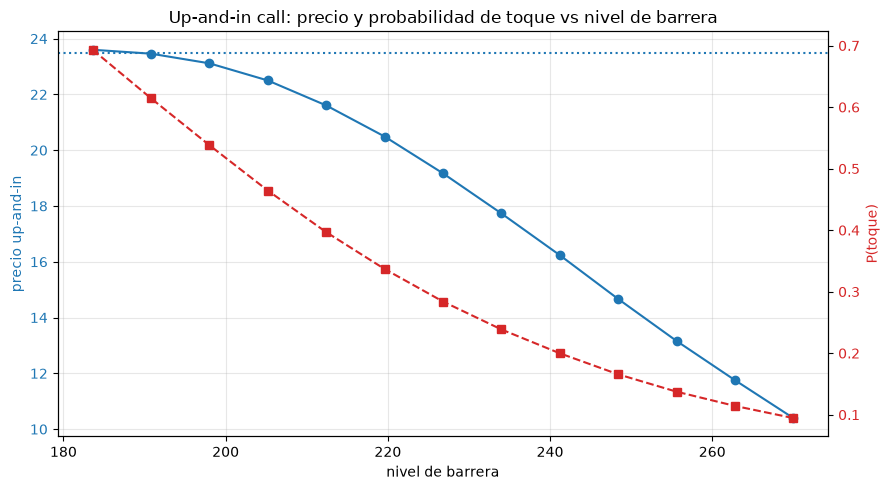

In [4]:
barrier_levels = np.arange(1.02, 1.51, 0.04) * S0
prices, hit_probs = [], []
for b in barrier_levels:
    contract = up_and_in("UI", float(b), vanilla_contract)
    result = price_contract(contract, f"UI_{b:.0f}", measures=("PayoffPriceQ", ("PayoffHitProbabilityQ", {"event": "UI"})))
    prices.append(result["PayoffPriceQ"].scalar)
    hit_probs.append(result["PayoffHitProbabilityQ"].scalar)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(barrier_levels, prices, "o-", color="tab:blue")
ax1.axhline(vanilla_price, color="tab:blue", linestyle=":", label="precio vanilla (limite si barrier->spot)")
ax1.set_xlabel("nivel de barrera")
ax1.set_ylabel("precio up-and-in", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(barrier_levels, hit_probs, "s--", color="tab:red")
ax2.set_ylabel("P(toque)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Up-and-in call: precio y probabilidad de toque vs nivel de barrera")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Corredor double knock-out: mas ancho, mas se acerca a la vanilla


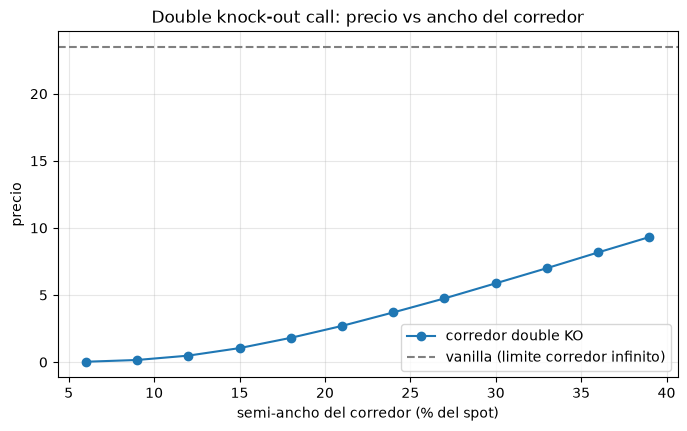

In [5]:
half_widths = np.arange(0.06, 0.41, 0.03)
corridor_prices = []
for hw in half_widths:
    contract = double_knock_out("KO", S0 * (1.0 - hw), S0 * (1.0 + hw), vanilla_contract)
    corridor_prices.append(price_contract(contract, f"KO_{hw:.2f}")["PayoffPriceQ"].scalar)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(half_widths * 100.0, corridor_prices, "o-", label="corredor double KO")
ax.axhline(vanilla_price, color="grey", linestyle="--", label="vanilla (limite corredor infinito)")
ax.set_xlabel("semi-ancho del corredor (% del spot)")
ax.set_ylabel("precio")
ax.set_title("Double knock-out call: precio vs ancho del corredor")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## 5. Digital/binario: `if_` + predicado

Un digital paga un importe fijo si el fixing final supera el strike -- construido con
`q.if_(condicion, cashflow, zero())`, sin necesidad de ningun nodo nuevo.


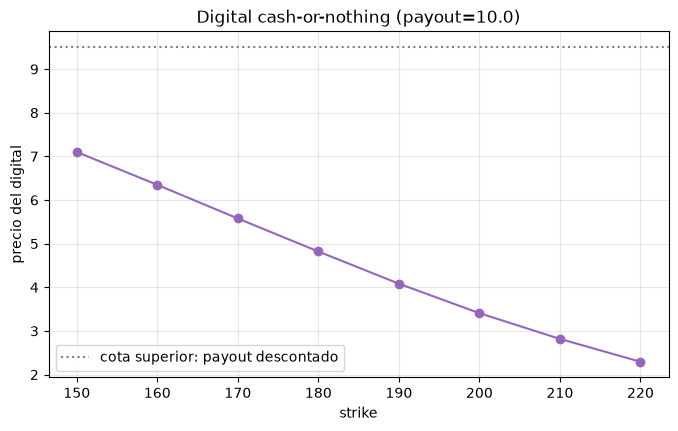

In [6]:
PAYOUT = 10.0
strikes = np.arange(150.0, 221.0, 10.0)
digital_products = []
for k in strikes:
    contract = q.when(T, q.if_(q.greater(q.fixing(OBS, T), float(k)), q.cashflow("USD", PAYOUT), q.zero()))
    digital_products.append(eng.create_product("Payoff", q.PayoffProduct(id=f"DIG_{k:.0f}", contract=contract).to_params()))

rows = eng.price_many(digital_products, ["PayoffPriceQ"], model, market, pricing, execution)
digital_prices = [row.measures["PayoffPriceQ"].scalar for row in rows]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(strikes, digital_prices, "o-", color="tab:purple")
ax.axhline(PAYOUT * math.exp(-R * T), color="grey", linestyle=":", label="cota superior: payout descontado")
ax.set_xlabel("strike")
ax.set_ylabel("precio del digital")
ax.set_title(f"Digital cash-or-nothing (payout={PAYOUT})")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## 6. Asiatico aritmetico: nodo nativo `q.average`

Desde `PLAN_IMPROVE_NOTEBOOK.md` Fase 2, `Average` esta cableado al compilador Monte Carlo
del payoff (`rust/crates/engine-core/src/payoff/compile.rs`): es una suma PONDERADA sobre un
`schedule` fijo (`sum(weights[i] * fixing(observable, schedule[i]))`, misma forma que el AST
de autoria ya existente en C++/`docs/schema/engine.payoff/v1.schema.json` -- NO una media con
divisor implicito), asi que un asiatico equiponderado usa `weights = [1/n]*n`.

La replica manual horneada a mano (`(fixing(t1)+...+fixing(tn))/n` via `add`/`div`) se
mantiene como celda de verificacion cruzada, no como unico camino (mismo patron que las
Fases 0/5 de `PLAN_IMPROVE_NOTEBOOK.md`): con la MISMA semilla/numero de trayectorias, ambos
caminos coinciden EXACTAMENTE (no solo dentro de ruido Monte Carlo), tal como exige el
criterio de aceptacion de la Fase 2.

average nativo vs horneado a mano (n=4): 15.767402 == 15.767402 (coinciden exactamente)


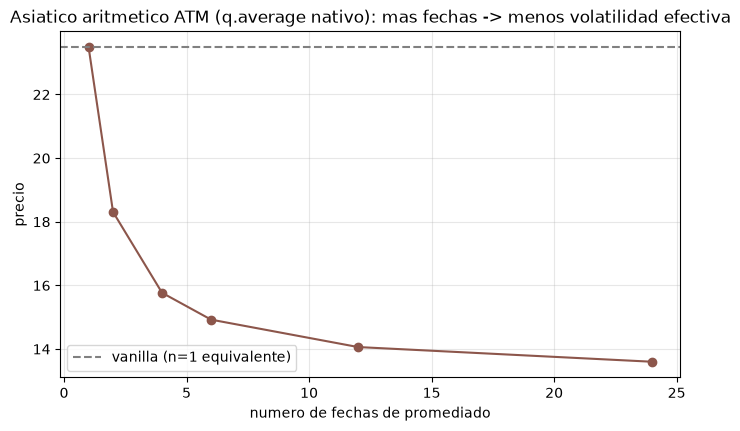

In [7]:
def asian_call_contract(n_dates, strike):
    """q.average nativo: suma ponderada equiponderada (weights=1/n) sobre un schedule fijo."""
    fixing_times = list(np.linspace(T / n_dates, T, n_dates))
    weights = [1.0 / n_dates] * n_dates
    average = q.average(OBS, fixing_times, weights)
    return q.when(T, q.cashflow("USD", q.maximum(average - strike, 0.0)))


def asian_call_contract_manual(n_dates, strike):
    """Replica horneada a mano (celda de verificacion cruzada, NO el unico camino): misma
    formula, construida con add/div sobre 'fixing' en vez del nodo 'average' nativo."""
    fixing_times = list(np.linspace(T / n_dates, T, n_dates))
    terms = [q.fixing(OBS, t) for t in fixing_times]
    total = terms[0]
    for term in terms[1:]:
        total = total + term
    average = total / float(n_dates)
    return q.when(T, q.cashflow("USD", q.maximum(average - strike, 0.0)))


# Verificacion cruzada: nativo vs horneado a mano deben coincidir EXACTAMENTE (misma seed/n_paths).
native_check = price_contract(asian_call_contract(4, S0), "ASIAN_NATIVE_CHECK")["PayoffPriceQ"].scalar
manual_check = price_contract(asian_call_contract_manual(4, S0), "ASIAN_MANUAL_CHECK")["PayoffPriceQ"].scalar
assert native_check == manual_check, f"nativo={native_check} manual={manual_check}"
print(f"average nativo vs horneado a mano (n=4): {native_check:.6f} == {manual_check:.6f} (coinciden exactamente)")

n_dates_grid = [1, 2, 4, 6, 12, 24]
asian_prices = []
for n in n_dates_grid:
    contract = asian_call_contract(n, S0)
    asian_prices.append(price_contract(contract, f"ASIAN_{n}")["PayoffPriceQ"].scalar)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(n_dates_grid, asian_prices, "o-", color="tab:brown")
ax.axhline(vanilla_price, color="grey", linestyle="--", label="vanilla (n=1 equivalente)")
ax.set_xlabel("numero de fechas de promediado")
ax.set_ylabel("precio")
ax.set_title("Asiatico aritmetico ATM (q.average nativo): mas fechas -> menos volatilidad efectiva")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 7. Lookback real: `running_max`/`running_min` (`PLAN_IMPROVE_NOTEBOOK.md` Fase 2)

Antes de esta fase, un lookback (payoff que depende del maximo/minimo CORRIDO de la
trayectoria, no de un conjunto fijo de fechas) no tenia ningun workaround posible con los
nodos soportados. `q.running_max`/`q.running_min` ya compilan, con una decision de diseno
importante: replican el AST de autoria ya existente (`docs/schema/engine.payoff/v1.schema.json`,
`cpp/engine/include/engine/payoff/expression.hpp`) y solo llevan el `observable`, SIN un
`schedule` propio -- el motor Rust reduce en evaluacion sobre los instantes YA conocidos en
preflight (`CompiledPayoff::required_times()`) que sean `<=` el instante en el que se usa el
resultado (ver el doc-comment de `ScalarOp::RunningMin` en
`rust/crates/engine-core/src/payoff/ir.rs`).

Practicamente, eso significa que si ningun otro nodo del contrato referencia fechas
intermedias del observable, `required_times()` no tiene mas puntos que el propio vencimiento.
Para dar al lookback un schedule de monitorizacion real (aqui, semanal) se usa una
`q.average` con `weights` a CERO como "ancla": no contribuye ningun importe (`0.0 * ancla`),
solo inyecta esas fechas en `required_times()` -- documentado, no oculto.

Un lookback call paga `max(running_max(S) - K, 0)`: como el maximo corrido siempre domina al
fixing final, su precio es >= el de la vanilla del mismo strike -- y crece con la frecuencia
de monitorizacion (mas oportunidades de capturar un pico mas alto). El lookback put
(`running_min`) es simetrico.

running_max nativo vs horneado a mano (52 fechas): 41.946712 == 41.946712 (coinciden exactamente)


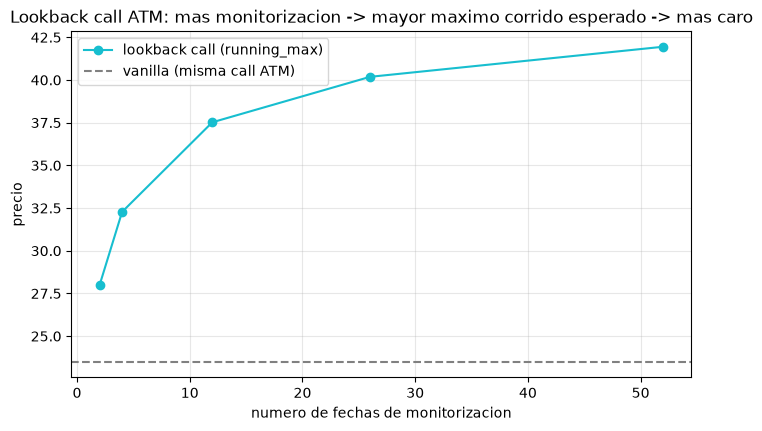

In [8]:
def _monitoring_anchor(dates):
    """'Ancla' de monitorizacion: un q.average con weights a cero, que no contribuye ningun
    importe pero inyecta 'dates' en required_times() -- ver la nota de la seccion. Patron
    documentado en el doc-comment de ScalarOp::RunningMin (ir.rs)."""
    return q.average(OBS, dates, [0.0] * len(dates))


def lookback_call_contract(monitoring_dates, strike):
    seeded_running_max = q.running_max(OBS) + 0.0 * _monitoring_anchor(monitoring_dates)
    return q.when(T, q.cashflow("USD", q.maximum(seeded_running_max - strike, 0.0)))


def lookback_call_contract_manual(monitoring_dates, strike):
    """Replica horneada a mano (celda de verificacion cruzada): encadena q.maximum sobre los
    mismos fixings, sin usar el nodo 'running_max' nativo."""
    running_max = q.fixing(OBS, monitoring_dates[0])
    for t in monitoring_dates[1:]:
        running_max = q.maximum(running_max, q.fixing(OBS, t))
    return q.when(T, q.cashflow("USD", q.maximum(running_max - strike, 0.0)))


weekly_dates = list(np.linspace(T / 52, T, 52))

# Verificacion cruzada: nativo vs horneado a mano deben coincidir EXACTAMENTE.
lookback_native_check = price_contract(
    lookback_call_contract(weekly_dates, S0), "LOOKBACK_NATIVE_CHECK"
)["PayoffPriceQ"].scalar
lookback_manual_check = price_contract(
    lookback_call_contract_manual(weekly_dates, S0), "LOOKBACK_MANUAL_CHECK"
)["PayoffPriceQ"].scalar
assert lookback_native_check == lookback_manual_check, (
    f"nativo={lookback_native_check} manual={lookback_manual_check}"
)
print(
    f"running_max nativo vs horneado a mano (52 fechas): "
    f"{lookback_native_check:.6f} == {lookback_manual_check:.6f} (coinciden exactamente)"
)

monitoring_grid = [2, 4, 12, 26, 52]
lookback_prices = []
for n in monitoring_grid:
    dates = list(np.linspace(T / n, T, n))
    lookback_prices.append(price_contract(lookback_call_contract(dates, S0), f"LOOKBACK_{n}")["PayoffPriceQ"].scalar)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(monitoring_grid, lookback_prices, "o-", color="tab:cyan", label="lookback call (running_max)")
ax.axhline(vanilla_price, color="grey", linestyle="--", label="vanilla (misma call ATM)")
ax.set_xlabel("numero de fechas de monitorizacion")
ax.set_ylabel("precio")
ax.set_title("Lookback call ATM: mas monitorizacion -> mayor maximo corrido esperado -> mas caro")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

assert all(p >= vanilla_price - 1e-6 for p in lookback_prices), "el lookback deberia dominar siempre a la vanilla"

In [9]:
# running_min (lookback put): mismo patron, simetrico.
def lookback_put_contract(monitoring_dates, strike):
    seeded_running_min = q.running_min(OBS) + 0.0 * _monitoring_anchor(monitoring_dates)
    return q.when(T, q.cashflow("USD", q.maximum(strike - seeded_running_min, 0.0)))


lookback_put_price = price_contract(lookback_put_contract(weekly_dates, S0), "LOOKBACK_PUT")["PayoffPriceQ"].scalar
vanilla_put_price = price_contract(
    q.when(T, q.cashflow("USD", q.maximum(S0 - q.fixing(OBS, T), 0.0))), "VANILLA_PUT_CHECK"
)["PayoffPriceQ"].scalar
print(
    f"lookback put (running_min, 52 semanas)={lookback_put_price:.3f}  "
    f"vanilla put ATM={vanilla_put_price:.3f}"
)
assert lookback_put_price >= vanilla_put_price - 1e-6, "el lookback put deberia dominar siempre a la vanilla put"

lookback put (running_min, 52 semanas)=29.110  vanilla put ATM=15.964


## 8. Take-profit / stop-loss

Estrategia intradia/swing tipica: dos `trigger`s con prioridad (`priority`) y exclusion mutua
via `event_occurred` (patron de `docs/schema/engine.payoff/examples/tp_sl.json`). Se revisa
en `MONITORING` y paga la diferencia frente al precio de entrada en el primer evento que
dispare.


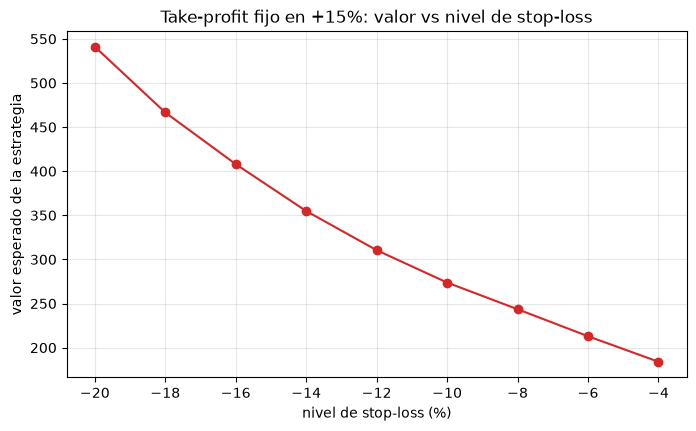

In [10]:
def take_profit_stop_loss_contract(entry_price, quantity, tp_return, sl_return, monitoring_times):
    ratio = q.div(q.current(OBS), entry_price) - 1.0
    tp_condition = q.all_of([q.greater_equal(ratio, tp_return), q.negate(q.event_occurred("STOP_LOSS"))])
    sl_condition = q.all_of([q.less_equal(ratio, sl_return), q.negate(q.event_occurred("TAKE_PROFIT"))])
    tp_payoff = q.cashflow("USD", quantity * (q.event_value("TAKE_PROFIT", OBS) - entry_price))
    sl_payoff = q.cashflow("USD", quantity * (q.event_value("STOP_LOSS", OBS) - entry_price))
    take_profit = q.trigger("TAKE_PROFIT", monitoring_times, tp_condition, "discrete", "at_hit", 10, True, tp_payoff, q.zero())
    stop_loss = q.trigger("STOP_LOSS", monitoring_times, sl_condition, "discrete", "at_hit", 20, True, sl_payoff, q.zero())
    return q.both([take_profit, stop_loss])


entry_price, quantity = S0, 100.0
monthly = [t / 12.0 for t in range(1, 13)]
tp_return = 0.15
sl_returns = np.arange(-0.20, -0.02, 0.02)
tp_sl_prices = []
for sl_return in sl_returns:
    contract = take_profit_stop_loss_contract(entry_price, quantity, tp_return, float(sl_return), monthly)
    tp_sl_prices.append(price_contract(contract, f"TPSL_{sl_return:.2f}")["PayoffPriceQ"].scalar)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sl_returns * 100.0, tp_sl_prices, "o-", color="tab:red")
ax.set_xlabel("nivel de stop-loss (%)")
ax.set_ylabel("valor esperado de la estrategia")
ax.set_title(f"Take-profit fijo en +{tp_return:.0%}: valor vs nivel de stop-loss")
ax.grid(alpha=0.3)
plt.show()


## 9. Combinaciones: straddle y strangle (`both`)

Un straddle (call+put mismo strike) y un strangle (call+put strikes distintos, fuera de
dinero) se construyen sin ningun concepto nuevo: `both([...])` suma dos contratos.


put_leg vs horneado a mano: 15.963952 == 15.963952 (coinciden exactamente)


custom_strategy(straddle) vs both([...]) a mano: 39.464649 == 39.464649 (coinciden exactamente)


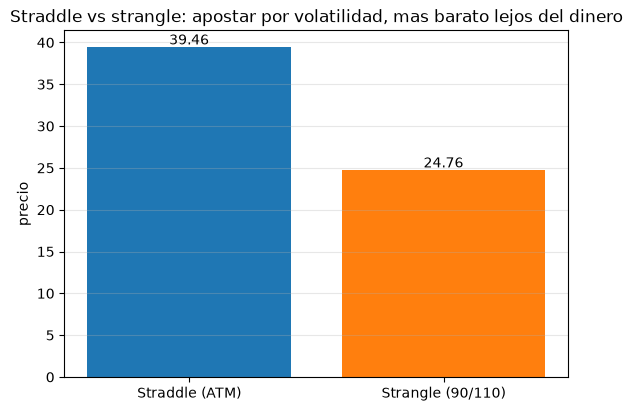

In [11]:
def vanilla_put_contract(strike):
    """Delega en engine_typed.payoff.put_leg (PLAN_IMPROVE_NOTEBOOK2.md Fase 6) -- ver
    vanilla_put_contract_manual para la version local horneada a mano (celda de verificacion
    cruzada, PRE-Fase 6)."""
    return q.put_leg(OBS, strike, 1.0, T)


def vanilla_put_contract_manual(strike):
    return q.when(T, q.cashflow("USD", q.maximum(strike - q.fixing(OBS, T), 0.0)))


# Verificacion cruzada put: put_leg (motor) vs horneado a mano deben dar el MISMO precio exacto.
put_native_check = price_contract(vanilla_put_contract(S0), "PUT_NATIVE_CHECK")["PayoffPriceQ"].scalar
put_manual_check = price_contract(vanilla_put_contract_manual(S0), "PUT_MANUAL_CHECK")["PayoffPriceQ"].scalar
assert put_native_check == put_manual_check, f"put_leg={put_native_check} manual={put_manual_check}"
print(f"put_leg vs horneado a mano: {put_native_check:.6f} == {put_manual_check:.6f} (coinciden exactamente)")


def price_strategy(trade):
    """Precia un PayoffProduct (p.ej. el que devuelve q.custom_strategy) sobre el mismo mercado
    que price_contract, sin duplicar el AST -- el combinador ya vive en custom_strategy."""
    product = eng.create_product(trade.product_type, trade.to_params())
    return eng.price(product, ["PayoffPriceQ"], model, market, pricing, execution)


strangle_low, strangle_high = S0 * 0.9, S0 * 1.1
straddle_trade = q.custom_strategy("STRADDLE", [q.call_leg(OBS, S0, 1.0, T), q.put_leg(OBS, S0, 1.0, T)])
strangle_trade = q.custom_strategy(
    "STRANGLE", [q.call_leg(OBS, strangle_high, 1.0, T), q.put_leg(OBS, strangle_low, 1.0, T)]
)

straddle_price = price_strategy(straddle_trade)["PayoffPriceQ"].scalar
strangle_price = price_strategy(strangle_trade)["PayoffPriceQ"].scalar

# Verificacion cruzada de estrategia: custom_strategy(call_leg, put_leg) vs el patron previo de
# este notebook (vanilla_call_contract_manual/vanilla_put_contract_manual + q.both([...]) a mano)
# deben dar el MISMO precio exacto.
straddle_manual_contract = q.both([vanilla_call_contract_manual(S0), vanilla_put_contract_manual(S0)])
straddle_manual_price = price_contract(straddle_manual_contract, "STRADDLE_MANUAL_CHECK")["PayoffPriceQ"].scalar
assert straddle_price == straddle_manual_price, f"custom_strategy={straddle_price} manual={straddle_manual_price}"
print(
    f"custom_strategy(straddle) vs both([...]) a mano: "
    f"{straddle_price:.6f} == {straddle_manual_price:.6f} (coinciden exactamente)"
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(["Straddle (ATM)", "Strangle (90/110)"], [straddle_price, strangle_price], color=["tab:blue", "tab:orange"])
for i, v in enumerate([straddle_price, strangle_price]):
    ax.text(i, v + 0.3, f"{v:.2f}", ha="center")
ax.set_ylabel("precio")
ax.set_title("Straddle vs strangle: apostar por volatilidad, mas barato lejos del dinero")
ax.grid(alpha=0.3, axis="y")
plt.show()
